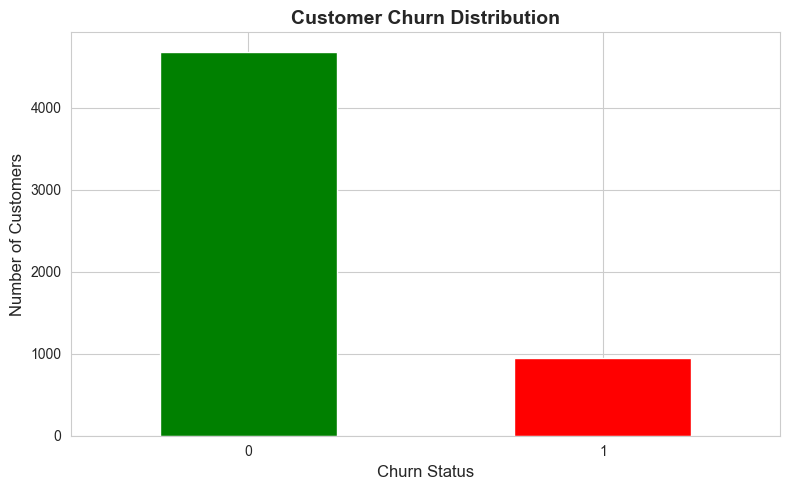

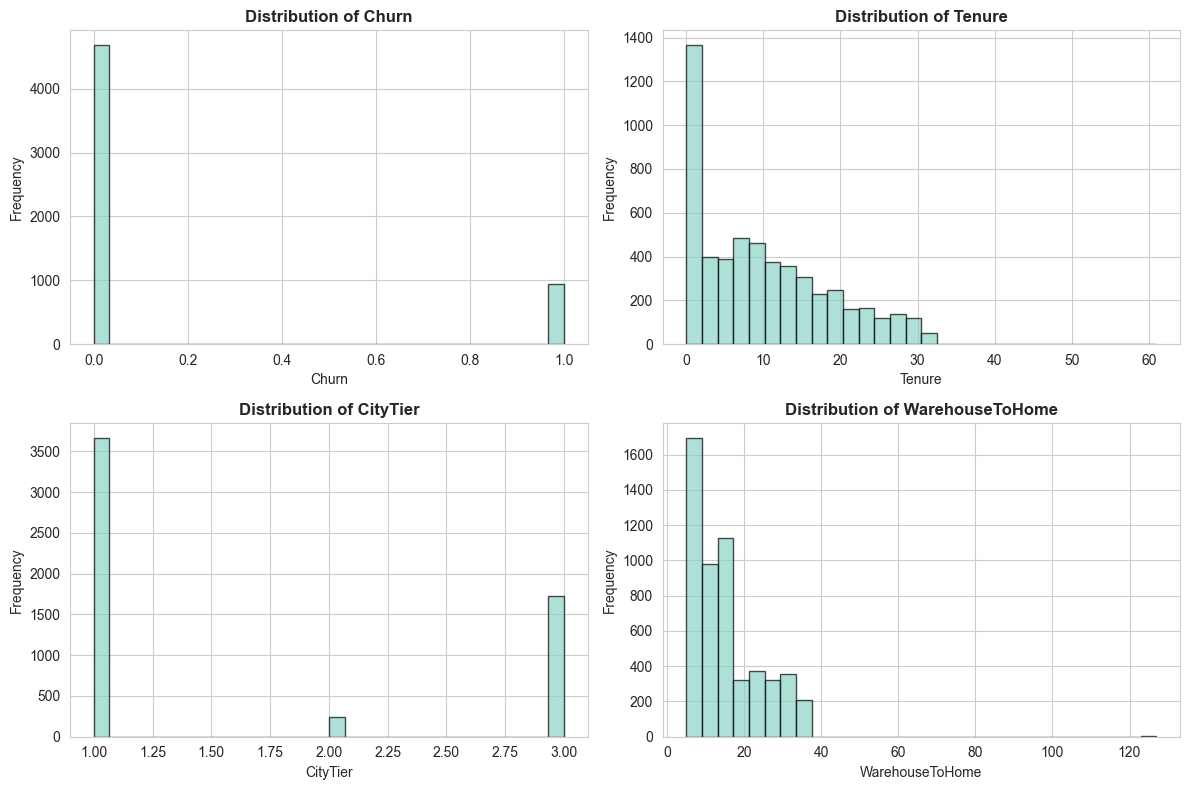

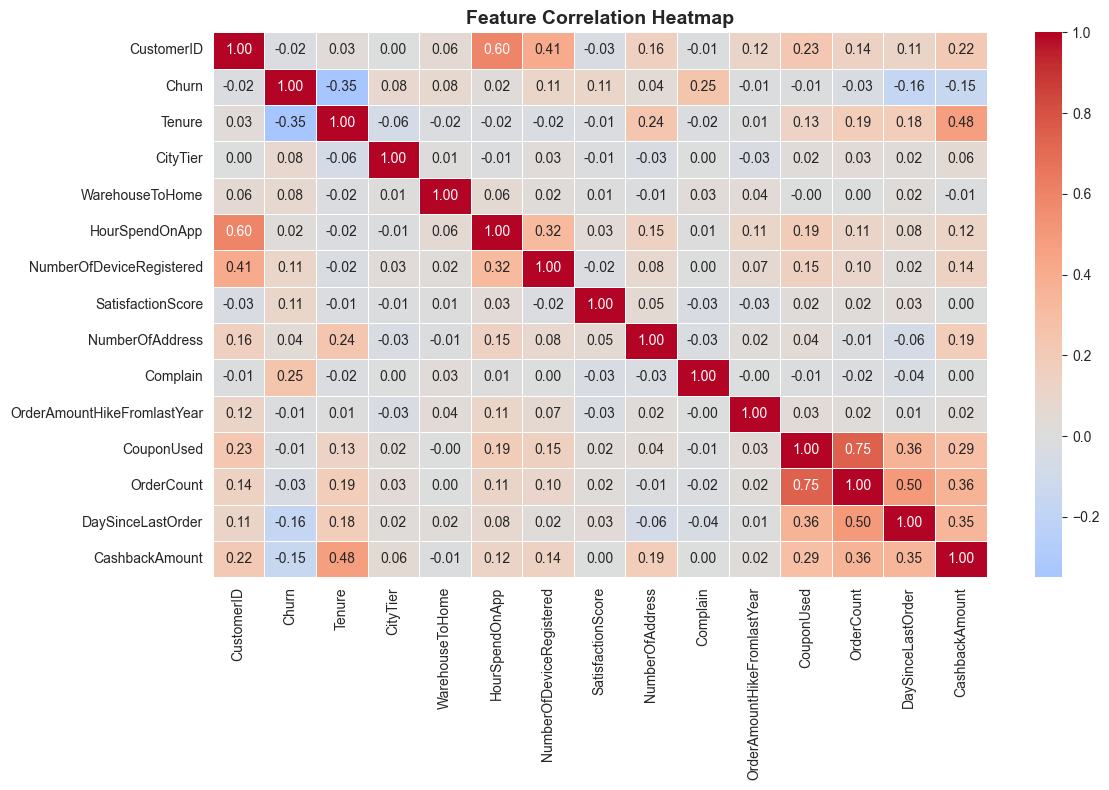


=== Data Preprocessing ===

 Best Model: Random Forest with 96.82% accuracy
              precision    recall  f1-score   support

    No Churn       0.97      0.99      0.98       629
       Churn       0.94      0.87      0.90       126

    accuracy                           0.97       755
   macro avg       0.96      0.93      0.94       755
weighted avg       0.97      0.97      0.97       755



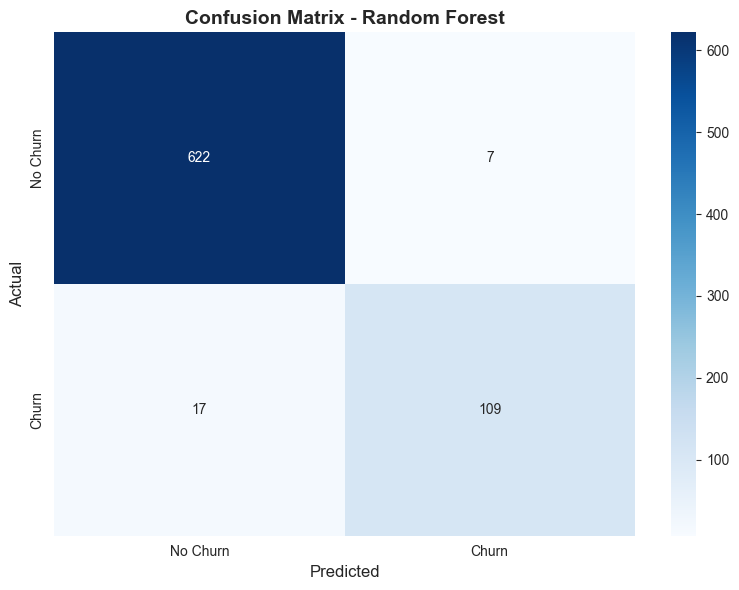


Example 1: Average Customer
 Prediction: No Churn
   Retention Probability: 100.00%

Example 2: Modified Customer Input
 Prediction: No Churn
   Retention Probability: 52.00%

Interface demonstration complete.
Changing inputs from Example 1 to Example 2 shows the model
responds to different customer attributes.
This can be seen if you manually alter all the key churn number indicators


In [21]:
# E-Commerce Customer Churn Prediction
# C964 Capstone Project
# Alantz Innocent

#Step 1- Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


#Step 2- Load Dataset
# Load the data
df = pd.read_csv('ecommerce_churn.csv')
df.head()


# Step 3- Method for Exploratory Data Analysis
# Exploratory data analysis techniques based on:
# Pandas documentation: https://pandas.pydata.org/docs/


# Check for missing values to inform data cleaning
missing = df.isnull().sum()


# Step 4- visualization highlighting customer target variables
# Visualization techniques using matplotlib and seaborn based on:
# Seaborn documentation: https://seaborn.pydata.org/
#This source was used as a guide for steps 4-6
# Find the churn column (might be 'Churn', 'churn', or similar)
churn_col = None
for col in df.columns:
    if 'churn' in col.lower():
        churn_col = col
        break

if churn_col:
    plt.figure(figsize=(8, 5))
    df[churn_col].value_counts().plot(kind='bar', color=['green', 'red'])
    plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Churn Status', fontsize=12)
    plt.ylabel('Number of Customers', fontsize=12)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


else:
    print("Churn column not found. Check column names.")


# Step 5- visual highlighting numerical id relationships
# Select numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove ID columns if present
numerical_cols = [col for col in numerical_cols if 'id' not in col.lower()]

# Plot distributions of first 4 numerical features
if len(numerical_cols) >= 4:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for i, col in enumerate(numerical_cols[:4]):
        df[col].hist(bins=30, ax=axes[i], edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Distribution of {col}', fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()


# STEP 6- a visualization represented via a heatmap
# Select numerical columns for correlation
corr_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(corr_cols) > 1:
    # Limit to a sizable length of numbers on display
    if len(corr_cols) > 15:
        corr_cols = corr_cols[:15]

    plt.figure(figsize=(12, 8))
    correlation_matrix = df[corr_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5)
    plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for correlation heatmap.")
    print("Creating alternative visualization...")

    # Alternative: Count plot of categorical variable
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    if len(categorical_cols) > 0:
        plt.figure(figsize=(10, 6))
        df[categorical_cols[0]].value_counts().head(10).plot(kind='barh')
        plt.title(f'Top 10 {categorical_cols[0]} Categories', fontsize=14, fontweight='bold')
        plt.xlabel('Count')
        plt.tight_layout()
        plt.show()

# Step 7- Cleaning and preparing data

print("\n=== Data Preprocessing ===")
# Drop ID columns if present
id_cols = [col for col in df.columns if 'id' in col.lower() or 'customer' in col.lower()]
df_clean = df.drop(columns=id_cols, errors='ignore')
# Handle missing values
df_clean = df_clean.dropna()
# Identify categorical columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# STEP 8: Encoding the category variables
# Reference: Scikit-learn documentation on LabelEncoder
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html


# Make a copy to preserve original
df_model = df_clean.copy()

# Find the churn column
churn_col = None
for col in df_model.columns:
    if 'churn' in col.lower():
        churn_col = col
        break
# Get categorical columns this will not include the target
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()
if churn_col in categorical_cols:
    categorical_cols.remove(churn_col)


# Encode categorical variables using labels that are encoded
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

# Encode target variable (Churn) if it's text
if df_model[churn_col].dtype == 'object':
    le_target = LabelEncoder()
    df_model[churn_col] = le_target.fit_transform(df_model[churn_col])

# STEP 9: Split Data into Features and Target
# Stratified sampling approach following best practices from:
# Scikit-learn train_test_split: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html


# Separate features (X) and target (y)
X = df_model.drop(columns=[churn_col])
y = df_model[churn_col]

# Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# STEP 10: Train Classification Models
# Model 1: Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_accuracy = accuracy_score(y_test, log_pred)


# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

# Select best model
if rf_accuracy > log_accuracy:
    best_model = rf_model
    best_model_name = "Random Forest"
    best_pred = rf_pred
    best_accuracy = rf_accuracy
else:
    best_model = log_model
    best_model_name = "Logistic Regression"
    best_pred = log_pred
    best_accuracy = log_accuracy

print(f"\n Best Model: {best_model_name} with {best_accuracy*100:.2f}% accuracy")

# STEP 11: Evaluate Model Performance
# Performance metrics and confusion matrix interpretation based on:
# Scikit-learn metrics documentation: https://scikit-learn.org/stable/modules/model_evaluation.html
# Detailed classification report
print(classification_report(y_test, best_pred,
                          target_names=['No Churn', 'Churn']))




# STEP 12: User Input Interface for Predictions

def predict_churn(input_data):
    """
    Make a churn prediction for a customer

    Parameters:
    input_data: dict with customer features

    Returns:
    prediction (0 or 1) and probability
    """
    input_df = pd.DataFrame([input_data])
    prediction = best_model.predict(input_df)[0]
    probability = best_model.predict_proba(input_df)[0]
    return prediction, probability

# Get feature names
feature_names = X_train.columns.tolist()
# Example 1: Average Customer (Baseline)

print("\n" + "="*60)
print("Example 1: Average Customer")
print("="*60)

sample_customer_1 = {col: X_train[col].median() for col in feature_names}

prediction_1, probability_1 = predict_churn(sample_customer_1)

if prediction_1 == 1:
    print(f"  Prediction: Churn")
    print(f"   Churn Probability: {probability_1[1]*100:.2f}%")
else:
    print(f" Prediction: No Churn")
    print(f"   Retention Probability: {probability_1[0]*100:.2f}%")

# EXAMPLE 2: Modified Customer Input
print("\n" + "="*60)
print("Example 2: Modified Customer Input")
print("="*60)

sample_customer_2 = {col: X_train[col].median() for col in feature_names}

# Modify key churn indicators
sample_customer_2['Tenure'] = 1.0
sample_customer_2['SatisfactionScore'] = 0.0
sample_customer_2['Complain'] = 3.0
sample_customer_2['OrderCount'] = 6.0
sample_customer_2['DaySinceLastOrder'] = 0.0
sample_customer_2['CashbackAmount'] = 2.0
sample_customer_2['HourSpendOnApp'] = 1.0

prediction_2, probability_2 = predict_churn(sample_customer_2)

if prediction_2 == 1:
    print(f"⚠  Prediction: Churn")
    print(f"   Churn Probability: {probability_2[1]*100:.2f}%")
else:
    print(f" Prediction: No Churn")
    print(f"   Retention Probability: {probability_2[0]*100:.2f}%")

print("\n" + "="*60)
print("Interface demonstration complete.")
print("Changing inputs from Example 1 to Example 2 shows the model")
print("responds to different customer attributes.")
print("This can be seen if you manually alter all the key churn number indicators")
print("="*60)
